In [154]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [155]:
df = pd.read_csv("ford.csv")
print(df.head())
df.shape


     model  year  price transmission  mileage fuelType  tax   mpg  engineSize
0   Fiesta  2017  12000    Automatic    15944   Petrol  150  57.7         1.0
1    Focus  2018  14000       Manual     9083   Petrol  150  57.7         1.0
2    Focus  2017  13000       Manual    12456   Petrol  150  57.7         1.0
3   Fiesta  2019  17500       Manual    10460   Petrol  145  40.3         1.5
4   Fiesta  2019  16500    Automatic     1482   Petrol  145  48.7         1.0


(17966, 9)

In [156]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  str    
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  str    
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  str    
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), str(3)
memory usage: 1.2 MB


In [157]:
df['fuelType'].value_counts()

fuelType
Petrol      12179
Diesel       5762
Hybrid         22
Electric        2
Other           1
Name: count, dtype: int64

In [158]:
df['transmission'].value_counts()

transmission
Manual       15518
Automatic     1361
Semi-Auto     1087
Name: count, dtype: int64

In [159]:
df['model'].nunique() #Use nunique() to count how many distinct models are in the model column:
df['model'].value_counts()

#If you also want to see the actual model names:

#If you want both the names and how often each appears:

#So, for “how many models are available,” nunique() is the one you want.

model
 Fiesta                   6557
 Focus                    4588
 Kuga                     2225
 EcoSport                 1143
 C-MAX                     543
 Ka+                       531
 Mondeo                    526
 B-MAX                     355
 S-MAX                     296
 Grand C-MAX               247
 Galaxy                    228
 Edge                      208
 KA                        199
 Puma                       80
 Tourneo Custom             69
 Grand Tourneo Connect      59
 Mustang                    57
 Tourneo Connect            33
 Fusion                     16
 Streetka                    2
 Ranger                      1
 Escort                      1
 Transit Tourneo             1
Focus                        1
Name: count, dtype: int64

In [160]:
df.describe() ## describe method will always give us the result from numeric columns

,year,price,mileage,tax,mpg,engineSize
count,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000
mean,2016.866470,12279.534844,23362.608761,113.329456,57.906980,1.350807
std,2.050336,4741.343657,19472.054349,62.012456,10.125696,0.432367
min,1996.000000,495.000000,1.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,9987.000000,30.000000,52.300000,1.000000
50%,2017.000000,11291.000000,18242.500000,145.000000,58.900000,1.200000
75%,2018.000000,15299.000000,31060.000000,145.000000,65.700000,1.500000
max,2060.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000


In [161]:
# Now we can find if there is null values

df.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

In [162]:
df.duplicated().sum()

np.int64(154)

In [163]:
# If you want to see the duplicated rows themselves:
df[df.duplicated()]

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
159,Focus,2016,10995,Manual,30923,Diesel,0,74.3,1.5
312,Focus,2019,14998,Manual,7000,Petrol,145,58.9,1.0
349,Focus,2019,14998,Manual,7000,Petrol,145,58.9,1.0
510,EcoSport,2019,15489,Manual,5636,Diesel,145,68.9,1.5
512,Grand Tourneo Connect,2019,19999,Manual,3500,Diesel,145,61.4,1.5
...,...,...,...,...,...,...,...,...,...
14556,Mondeo,2015,6793,Manual,138000,Diesel,20,68.9,2.0
15121,Kuga,2017,14999,Manual,24877,Diesel,30,64.2,1.5
15127,EcoSport,2019,16799,Automatic,433,Petrol,150,45.6,1.0
15685,KA,2008,1795,Manual,63000,Petrol,160,45.6,1.3


In [164]:
duplicate_count = df.duplicated().sum()
print(f"Exact duplicate rows: {duplicate_count}")

duplicate_rows = df[df.duplicated(keep=False)]
duplicate_rows.sort_values(list(df.columns))


Exact duplicate rows: 154


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
8480,B-MAX,2013,6995,Manual,31472,Petrol,30,57.7,1.0
9406,B-MAX,2013,6995,Manual,31472,Petrol,30,57.7,1.0
10224,B-MAX,2014,6995,Manual,17441,Diesel,20,68.9,1.5
10272,B-MAX,2014,6995,Manual,17441,Diesel,20,68.9,1.5
10237,B-MAX,2017,9495,Manual,32442,Petrol,145,55.4,1.0
...,...,...,...,...,...,...,...,...,...
13451,S-MAX,2019,25000,Manual,9544,Diesel,145,54.3,2.0
8262,S-MAX,2019,29499,Semi-Auto,8998,Diesel,145,51.4,2.0
9046,S-MAX,2019,29499,Semi-Auto,8998,Diesel,145,51.4,2.0
9233,Tourneo Connect,2016,11995,Manual,21026,Diesel,30,64.2,1.5


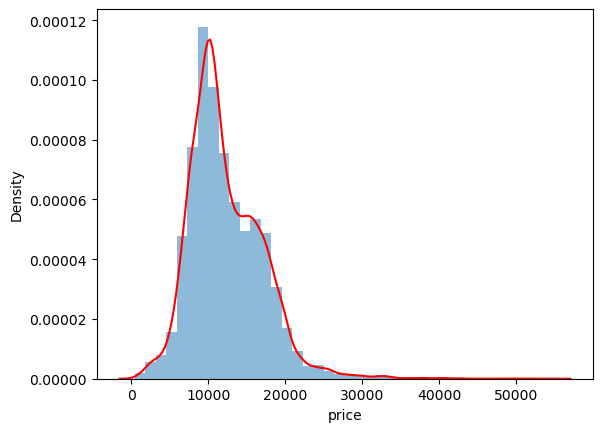

In [165]:
#EDA - Exploratory data analysis:
# if you use sns(seaborn) then write histplot and for plt use hist
#sns.histplot(df['price'], bins=40, kde=True)

#plt.hist(df['price'],bins=40)
plt.hist(df["price"], bins=40, alpha=0.5, density=True)
sns.kdeplot(df["price"], color="red")
plt.show()

<Axes: >

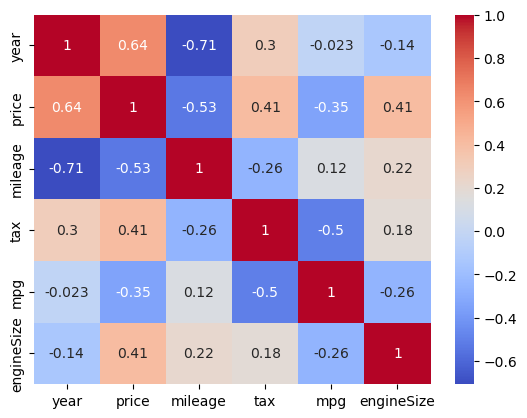

In [166]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

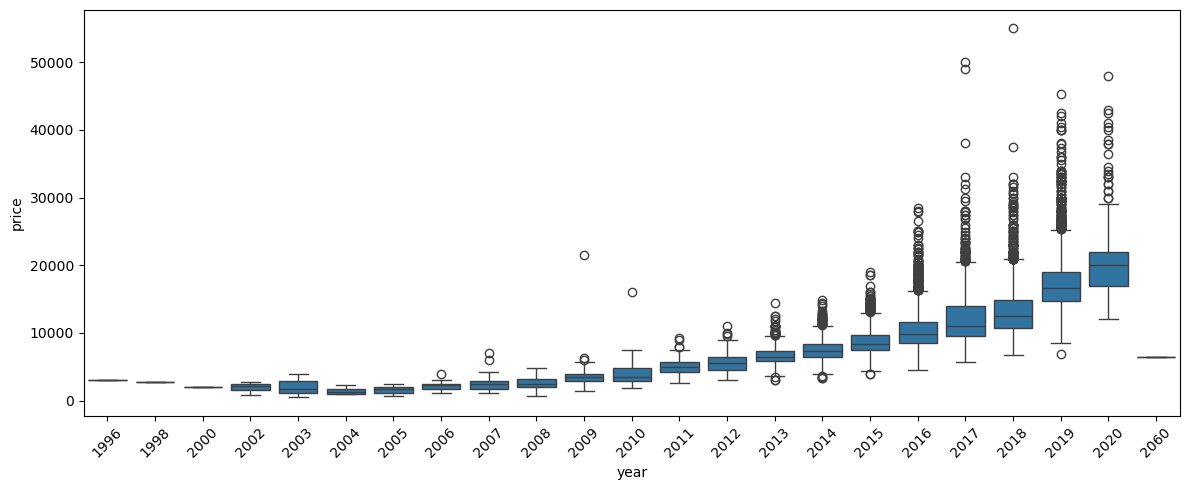

In [167]:
# plt.figure(figsize=(16,8))
# sns.boxplot(data =df, x = 'year', y='price')
plt.figure(figsize=(12, 5))
ax = sns.boxplot(data=df, x="year", y="price")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

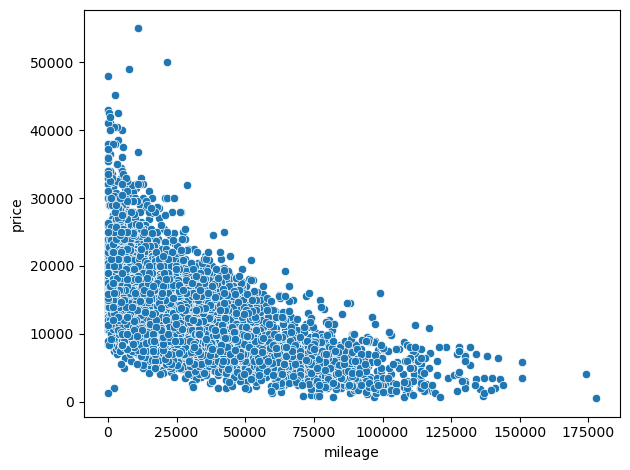

In [168]:
sns.scatterplot(data=df,x='mileage', y='price')
plt.tight_layout()
plt.show()

In [169]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='str')

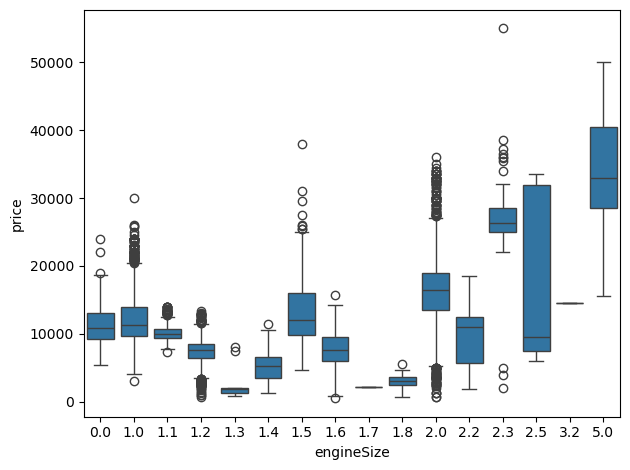

In [170]:
sns.boxplot(data=df, x= 'engineSize', y='price')
plt.tight_layout()
plt.show()

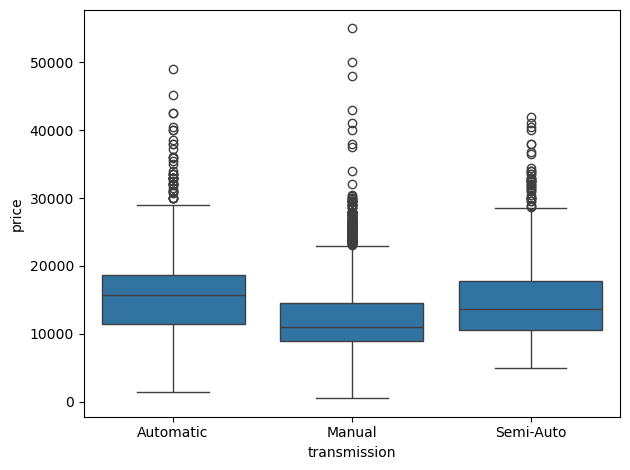

In [171]:
sns.boxplot(data=df, x='transmission', y= 'price')
plt.tight_layout()
plt.show()

<Axes: xlabel='fuelType', ylabel='price'>

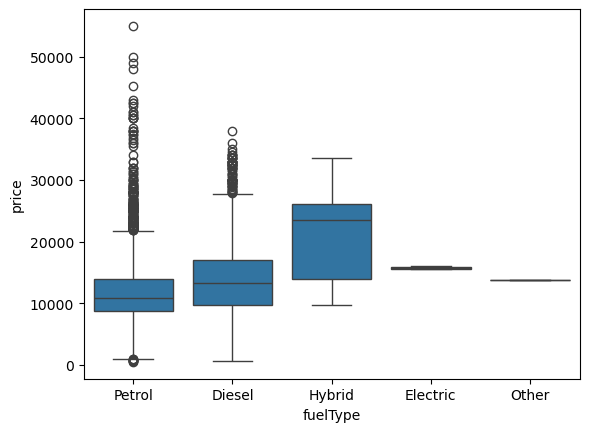

In [172]:
sns.boxplot(data=df, x='fuelType', y='price')

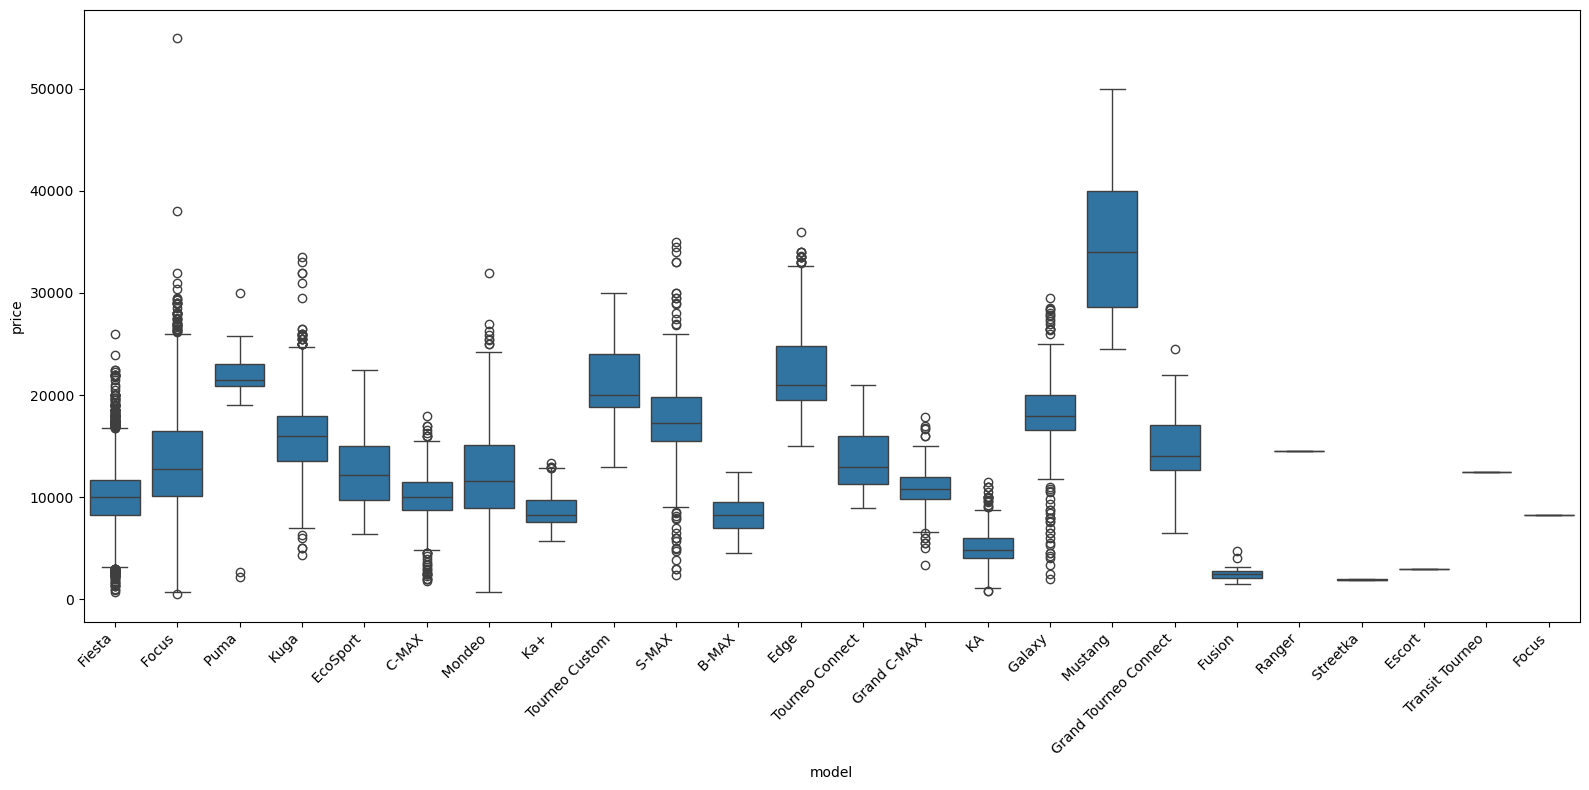

In [173]:
plt.figure(figsize=(16,8))
sns.boxplot(data=df, x='model', y='price')
plt.xticks(rotation =45, ha = 'right')
plt.tight_layout()
plt.show()

<Axes: xlabel='tax', ylabel='price'>

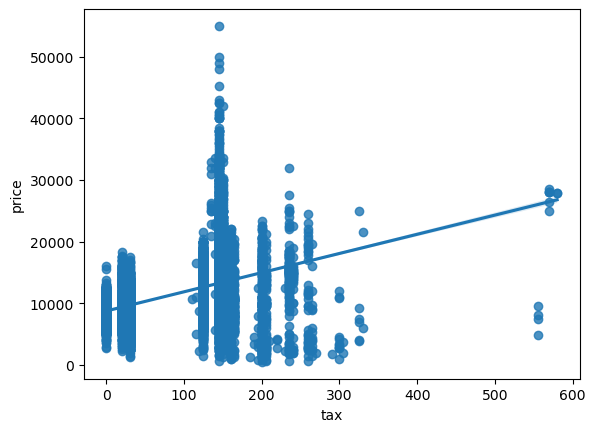

In [174]:
sns.regplot(data=df, x='tax', y='price')

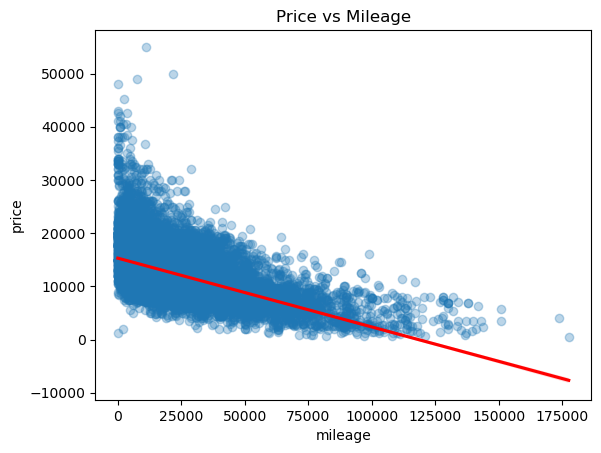

In [175]:
sns.regplot(data=df, x="mileage", y="price", scatter_kws={"alpha":0.3}, line_kws={"color":"red"})
plt.title("Price vs Mileage")
plt.show()

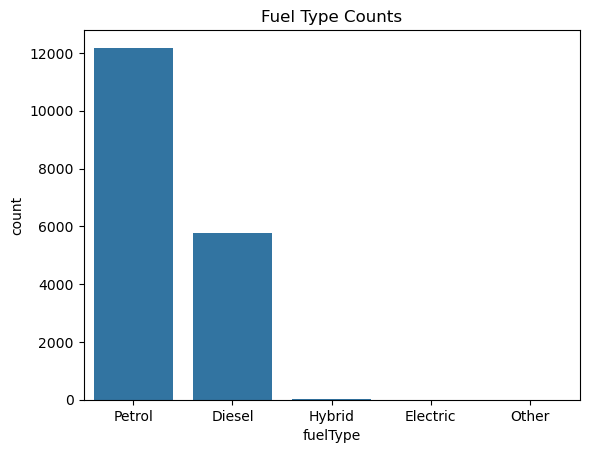

In [176]:
sns.countplot(data=df, x="fuelType")
plt.title("Fuel Type Counts")
plt.show()

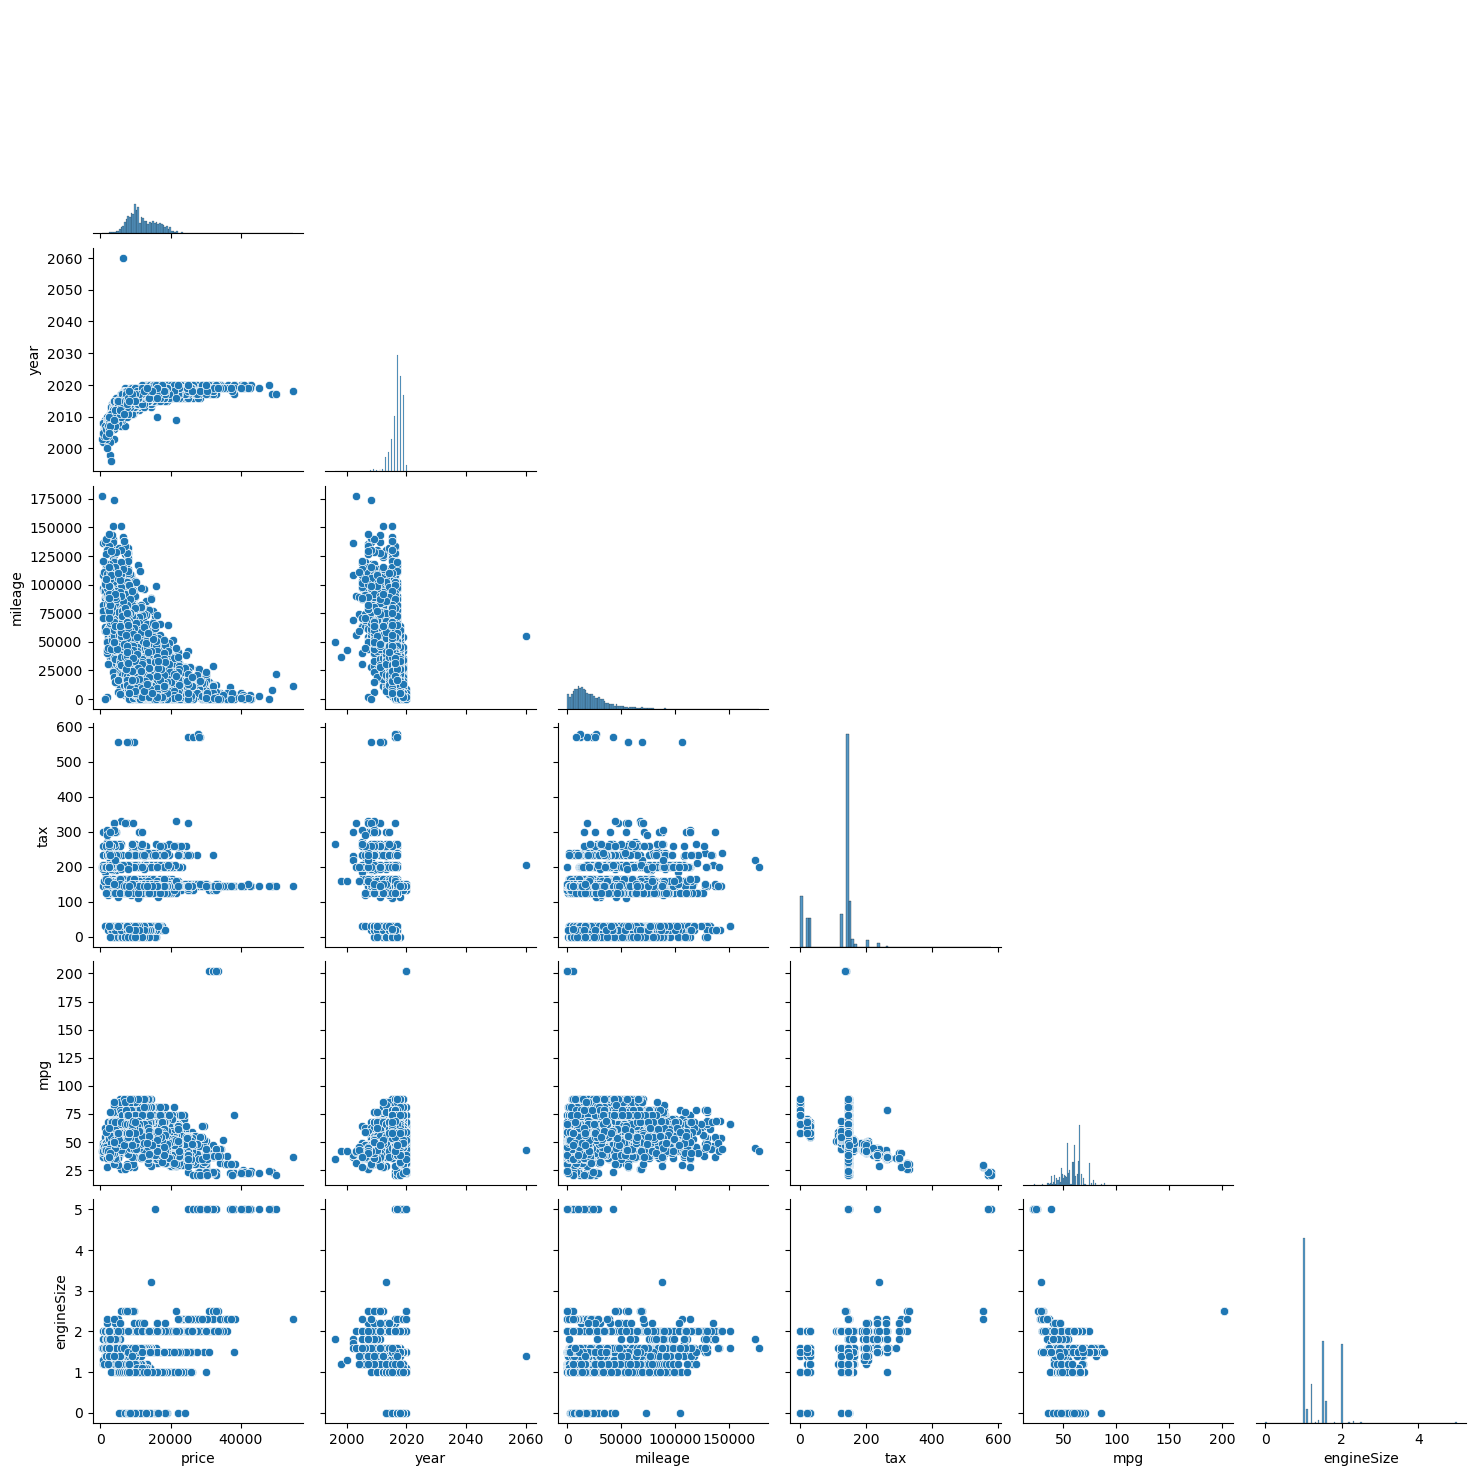

In [177]:
sns.pairplot(df[["price","year","mileage","tax","mpg","engineSize"]], corner=True)
plt.show()

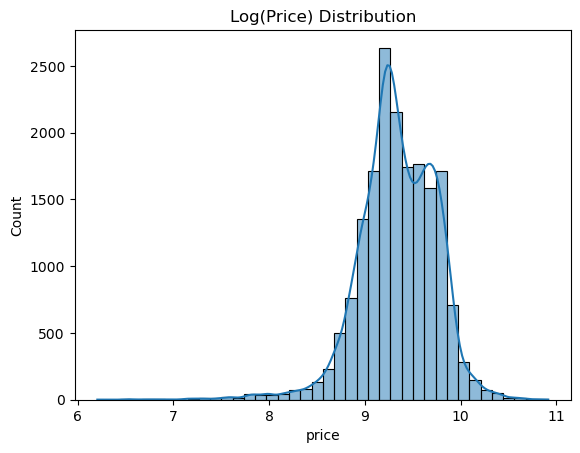

In [178]:
sns.histplot(np.log1p(df["price"]), bins=40, kde=True)
plt.title("Log(Price) Distribution")
plt.show()

In [179]:
X = df.drop('price', axis= 1)
y = df['price']
X

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,Automatic,1482,Petrol,145,48.7,1.0
...,...,...,...,...,...,...,...,...
17961,B-MAX,2017,Manual,16700,Petrol,150,47.1,1.4
17962,B-MAX,2014,Manual,40700,Petrol,30,57.7,1.0
17963,Focus,2015,Manual,7010,Diesel,20,67.3,1.6
17964,KA,2018,Manual,5007,Petrol,145,57.7,1.2


# Here i am doing one hot code dropping first column


In [180]:
#Here 
X_one_encode = pd.get_dummies(X, columns=['model', 'transmission','fuelType'],drop_first= True, dtype=int)
X_one_encode

,year,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,model_ Fiesta,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2017,15944,150,57.7,1.0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
1,2018,9083,150,57.7,1.0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,2017,12456,150,57.7,1.0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,2019,10460,145,40.3,1.5,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
4,2019,1482,145,48.7,1.0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,2017,16700,150,47.1,1.4,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17962,2014,40700,30,57.7,1.0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17963,2015,7010,20,67.3,1.6,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
17964,2018,5007,145,57.7,1.2,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1


## Now i will do label encoding for my learning purpose


In [181]:
from sklearn.preprocessing import LabelEncoder


columns = ['model','transmission','fuelType']

Xlabel = X.copy()
for col in columns:
    le = LabelEncoder()
    Xlabel[col] = le.fit_transform(Xlabel[col])

Xlabel


,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,5,2017,0,15944,4,150,57.7,1.0
1,6,2018,1,9083,4,150,57.7,1.0
2,6,2017,1,12456,4,150,57.7,1.0
3,5,2019,1,10460,4,145,40.3,1.5
4,5,2019,0,1482,4,145,48.7,1.0
...,...,...,...,...,...,...,...,...
17961,0,2017,1,16700,4,150,47.1,1.4
17962,0,2014,1,40700,4,30,57.7,1.0
17963,6,2015,1,7010,0,20,67.3,1.6
17964,11,2018,1,5007,4,145,57.7,1.2


## Now we will use standardization
When to use standardization

Algorithms based on distance or gradients:
KNN, SVM, Logistic Regression, Linear Regression (with regularization), Neural Networks, PCA.
Use standardization (z-score) most of the time.
Use normalization (min-max) when you specifically need a fixed range like 0 to 1.

In [182]:
from sklearn.preprocessing import StandardScaler
numerical_cols =['year', 'mileage', 'tax', 'mpg', 'engineSize']
scaler = StandardScaler()

X_one_encode[numerical_cols] = scaler.fit_transform(X_one_encode[numerical_cols])
X_one_encode[numerical_cols]
X_one_encode

,year,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,model_ Fiesta,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,0.065128,-0.380998,0.591358,-0.020442,-0.811386,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
1,0.552866,-0.733359,0.591358,-0.020442,-0.811386,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0.065128,-0.560132,0.591358,-0.020442,-0.811386,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,1.040605,-0.662640,0.510727,-1.738890,0.345070,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
4,1.040605,-1.123724,0.510727,-0.909294,-0.811386,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,0.065128,-0.342172,0.591358,-1.067312,0.113779,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17962,-1.398088,0.890398,-1.343791,-0.020442,-0.811386,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
17963,-0.910349,-0.839822,-1.505053,0.927668,0.576362,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
17964,0.552866,-0.942690,0.510727,-0.020442,-0.348804,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1


In [183]:
Xlabel.columns
Xlabel_scaled = scaler.fit_transform(Xlabel)
Xlabel_scaled = pd.DataFrame(Xlabel_scaled, columns=Xlabel.columns)
Xlabel_scaled

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,-0.460699,0.065128,-2.670032,-0.380998,0.688777,0.591358,-0.020442,-0.811386
1,-0.211477,0.552866,0.041351,-0.733359,0.688777,0.591358,-0.020442,-0.811386
2,-0.211477,0.065128,0.041351,-0.560132,0.688777,0.591358,-0.020442,-0.811386
3,-0.460699,1.040605,0.041351,-0.662640,0.688777,0.510727,-1.738890,0.345070
4,-0.460699,1.040605,-2.670032,-1.123724,0.688777,0.510727,-0.909294,-0.811386
...,...,...,...,...,...,...,...,...
17961,-1.706810,0.065128,0.041351,-0.342172,0.688777,0.591358,-1.067312,0.113779
17962,-1.706810,-1.398088,0.041351,0.890398,0.688777,-1.343791,-0.020442,-0.811386
17963,-0.211477,-0.910349,0.041351,-0.839822,-1.454098,-1.505053,0.927668,0.576362
17964,1.034634,0.552866,0.041351,-0.942690,0.688777,0.510727,-0.020442,-0.348804


In [184]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [185]:
X_train, X_test, y_train, y_test = train_test_split(X_one_encode, y, test_size=0.2, random_state=42)

In [186]:
model = LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [187]:
y_pred = model.predict(X_test)
y_pred

array([ 6644.59418325,  9190.94182499,  9815.67023063, ...,
       30065.02191131,  9629.26949625, 15117.00750876], shape=(3594,))

In [188]:
y_test

17610     6995
7076      8999
1713      7998
1611      5491
16830     3790
         ...  
7731     22000
11655    13699
10536    24979
11885    10500
4032     19718
Name: price, Length: 3594, dtype: int64

In [189]:
for actual, pred in list(zip(y_test, y_pred))[:20]:
    print(f"Actual: {actual:.2f}  |  Predicted: {pred:.2f}")

Actual: 6995.00  |  Predicted: 6644.59
Actual: 8999.00  |  Predicted: 9190.94
Actual: 7998.00  |  Predicted: 9815.67
Actual: 5491.00  |  Predicted: 3820.17
Actual: 3790.00  |  Predicted: 2681.71
Actual: 18200.00  |  Predicted: 16591.35
Actual: 22998.00  |  Predicted: 28710.59
Actual: 11000.00  |  Predicted: 12185.10
Actual: 7600.00  |  Predicted: 11553.58
Actual: 14985.00  |  Predicted: 16796.94
Actual: 13995.00  |  Predicted: 14780.86
Actual: 10995.00  |  Predicted: 13952.18
Actual: 9675.00  |  Predicted: 11464.82
Actual: 10990.00  |  Predicted: 11159.79
Actual: 12989.00  |  Predicted: 13971.01
Actual: 17498.00  |  Predicted: 15166.12
Actual: 9000.00  |  Predicted: 7898.52
Actual: 9650.00  |  Predicted: 12226.26
Actual: 17800.00  |  Predicted: 18159.64
Actual: 10246.00  |  Predicted: 10540.87


In [213]:
r2 = r2_score(y_test,y_pred)
r2

0.8458422267142565

### Adjusted R^2 is a corrected version of R^2 that penalizes adding too many input features.

What it does:

1. Normal R^2 never decreases when you add more features, even useless ones.
2. Adjusted R^2 increases only if a new feature truly improves the model enough.
3. So it is better for comparing models with different numbers of predictors.
Formula:


Adjusted R^2= 1−(1−R^2) (n-1)/(n-p-1)


​where 
* n = number of samples means rows and 
* p = number of predictors(features)
Interpretation:

1. If Adjusted R^2 is much lower than 
R^2, model may have unnecessary features.
2. If both are close, features are likely meaningful.
3. Higher is better, but always check MAE/RMSE too.


In [214]:
# now we will calculate Adjusted R^2 and if adjusted R^2 
# is much lower than R^2, model may have unnecessary features.
n = X_test.shape[0]
p = X_test.shape[1]

adjusted_r2 = 1 -((1-r2)*(n-1))/(n-p-1)
adjusted_r2

0.8454982205256132

In [207]:
X_train, X_test, y_train, y_test = train_test_split(Xlabel_scaled, y, test_size=0.2, random_state=42)

In [212]:
model2 = LinearRegression()
model2.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [209]:
y_pred2 = model2.predict(X_test)
y_pred2

array([ 6152.07567671,  9374.39134399,  9464.92264335, ...,
       21787.05312508,  9776.43926374, 15806.24990719], shape=(3594,))

In [215]:
r2 = r2_score(y_test,y_pred2)
r2

0.7365884288851354